<div style="
    text-align: center; 
    background: linear-gradient(135deg, #0062ff 0%, #00d4ff 100%); 
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; 
    color: white; 
    padding: 35px 20px; 
    border-radius: 15px; 
    box-shadow: 0 10px 25px rgba(0, 98, 255, 0.3);
    margin-bottom: 25px;">
    <div style="font-size: 35px; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; line-height: 1.2;">
        Trực Quan Hóa Dữ Liệu - Lab 01
    </div>
    <div style="font-size: 20px; font-weight: 500; margin-top: 10px; font-style: italic; opacity: 0.9;">
        "Phân tích thị trường mỹ phẩm nội và ngoại trên Tiki"
    </div>
    <div style="font-size: 18px; font-weight: 600; margin-top: 15px; border-top: 1px solid rgba(255,255,255,0.4); display: inline-block; padding-top: 10px; letter-spacing: 1px;">
        NHÓM 05 - FIT-HCMUS
    </div>
</div>

<div style="text-align: center; font-size: 40px; font-weight: bold;">
  THƯƠNG HIỆU & HỆ SINH THÁI GIAN HÀNG
</div>

# **1. Thiết lập môi trường và nạp dữ liệu**
## **1.1. Thiết lập môi trường**

In [13]:
# Cài đặt các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style toàn cục cho các biểu đồ
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : False,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'figure.dpi'        : 130,
    'savefig.dpi'       : 150,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})

# Bảng màu nhất quán xuyên suốt
C_DOMESTIC = '#2563EB'   # xanh dương — hàng trong nước
C_IMPORT   = '#DC2626'   # đỏ         — hàng ngoài nước
PALETTE    = [C_DOMESTIC, C_IMPORT]
COUNTRY_COLORS = [
    '#EF4444','#F97316','#EAB308','#22C55E','#3B82F6',
    '#8B5CF6','#EC4899','#14B8A6','#F59E0B','#6366F1'
]

print('Các thư viện đã được cài đặt và cấu hình thành công!')

Các thư viện đã được cài đặt và cấu hình thành công!


## **1.2. Nạp dữ liệu**

In [14]:
# Nạp dữ liệu 
df = pd.read_csv('../data/tiki_cosmetics_processed.csv')

# Khôi phục Categorical ordered cho price_segment sau khi đọc CSV
price_order = ['Dưới 100k', '100k – 300k', '300k – 700k', '700k – 2tr', 'Trên 2tr']
df['price_segment'] = pd.Categorical(df['price_segment'], categories=price_order, ordered=True)

# Tập con theo origin
df_vn = df[df['origin_class_corrected'] == 'Trong nước'].copy()
df_nn = df[df['origin_class_corrected'] == 'Ngoài nước'].copy()

# Kiểm tra
print(f'Tổng sản phẩm  : {len(df):,}')
print(f'  Trong nước   : {len(df_vn):,} ({len(df_vn)/len(df)*100:.1f}%)')
print(f'  Ngoài nước   : {len(df_nn):,} ({len(df_nn)/len(df)*100:.1f}%)')
print(f'Số thương hiệu : {df["brand_name"].nunique():,}')
print(f'Số danh mục    : {df["category"].nunique()}')
print(f'Khoảng giá     : {df["price"].min():,.0f} – {df["price"].max():,.0f} VNĐ')
print()
df.head(3)

df

Tổng sản phẩm  : 7,179
  Trong nước   : 1,915 (26.7%)
  Ngoài nước   : 5,264 (73.3%)
Số thương hiệu : 956
Số danh mục    : 30
Khoảng giá     : 10,000 – 18,000,000 VNĐ



,product_id,name,name_clean,brand_name,seller_name,product_type,category,primary_category,origin_class_corrected,origin_corrected,...,estimated_revenue,is_official_store,is_authentic,has_authentic_badge,tiki_verified,availability,availability_label,sold_hidden_flag,has_name_duplicate,is_extreme_outlier
0,277375294,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Sữa rửa mặt dưỡng trắng cao cấp Hada Labo Prem...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,2461000,True,1,True,0,1,Còn hàng,False,False,False
1,277375219,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Sữa rửa mặt Hada Labo dưỡng ẩm cao cấp Premium...,Hada Labo,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,3069000,True,1,True,0,1,Còn hàng,False,False,False
2,276486487,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Sữa Rửa Mặt Rosette Làm Giảm Mụn Face Wash Pas...,Rosette,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Ngoài nước,Nhật Bản,...,932400,True,1,True,0,1,Còn hàng,False,False,False
3,276396782,Sữa rửa mặt X-Men 100g Detox/Sáng da/Ngừa mụn/...,Sữa rửa mặt X-Men Detox/Sáng da/Ngừa mụn/Kiểm ...,X-Men,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,1116000,True,1,True,0,1,Còn hàng,False,False,False
4,276022717,"Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...","Sữa rửa mặt cho nam Oxy sạch dịu nhẹ, kiềm dầu...",OXY,Tiki Trading,Skincare,Sữa rửa mặt,Sữa rửa mặt,Trong nước,Việt Nam,...,4582000,True,1,True,0,1,Còn hàng,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7174,181806537,Xịt Mọc Tóc Perfect Hair Peptide 50ml Giúp Mọc...,"Xịt Mọc Tóc Perfect Hair Peptide Giúp Mọc Tóc,...",OEM,Beauty Tokyo,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Nhật Bản,...,0,False,0,False,0,1,Còn hàng,False,False,False
7175,77673658,Mascara Chuốt Tóc Con Forcolour Giữ Nếp Tóc & ...,Mascara Chuốt Tóc Con Forcolour Giữ Nếp Tóc & ...,FORCOLOUR,Mỹ Phẩm Auth 68,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Trung Quốc,...,8050000,True,1,True,1,1,Còn hàng,False,False,False
7176,41369694,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavening...,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavening...,HEAVENING,Hàng tiêu dùng nhập khẩu Shop,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Hàn Quốc,...,0,True,1,True,1,1,Còn hàng,False,False,False
7177,41356968,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavenin...,Bộ chăm sóc tóc dưỡng chất suôn mượt Heavening...,HEAVENING,Hàng tiêu dùng nhập khẩu Shop,Hair Care,Bộ chăm sóc tóc,Bộ chăm sóc tóc,Ngoài nước,Hàn Quốc,...,0,True,1,True,1,1,Còn hàng,False,False,False


# **2. Phân tích, trực quan hóa dữ liệu và kết luận**
## **2.1. Mục tiêu 1:** So sánh mức độ xác nhận thương hiệu (Tiki Verified) giữa mỹ phẩm nội địa và nhập khẩu dựa trên bộ dữ liệu từ tháng 3/2026 để đánh giá mức độ đầu tư xây dựng uy tín trên nền tảng của từng nhóm.
### **2.1.1. Lí do chọn mục tiêu**

*Tiki Verified* là dấu xác nhận Tiki cấp cho thương hiệu đã đăng ký chính thức và cam kết về chất lượng — không phải tự gán mà phải trải qua quy trình kiểm duyệt. Đây là chỉ số phản ánh mức độ đầu tư xây dựng uy tín trên nền tảng, phân tích chỉ số này giúp xác định nhóm nào đang chủ động đầu tư vào việc xây dựng hình ảnh thương hiệu trên Tiki, đánh giá tác động thực tế của Tiki Verified lên lượt bán và mức độ tương tác của người mua và giúp nhận diện danh mục sản phẩm nào đang được xác nhận nhiều hơn, từ đó hiểu xu hướng chuyên nghiệp hóa theo ngành

- Đối với *chủ doanh nghiệp mỹ phẩm*: Cần biết vị thế của mình để quyết định đầu tư vào hệ thống gian hàng chính hãng uy tín được xác nhận bởi Tiki nhằm tăng tỉ lệ chuyển đổi.

- Đối với *sàn thương mại điện tử (Tiki)*: Hiểu được mức độ trưởng thành của các thương hiệu nội địa để có chính sách hỗ trợ, thúc đẩy doanh nghiệp Việt được verify, giúp thị trường mỹ phẩm Việt tăng trưởng trên thương trường quốc tế.

### **2.1.2. Phân tích và trực quan hóa dữ liệu**
**Hành động cụ thể:** Phân tích, so sánh.

**Biểu đồ lựa chọn:** 

- *Biểu đồ thanh xếp chồng 100% (100% Stacked Bar Chart)*: Ta sử dụng biểu đồ này để so sánh tỉ lệ Tiki Verified giữa nội và ngoại, đây là lựa chọn tối ưu nhất để so sánh cơ cấu bên trong của hai nhóm có quy mô khác nhau. Nó loại bỏ sự chênh lệch về tổng số lượng sản phẩm, chỉ tập trung vào việc nhóm nào có tỷ lệ "chính hãng" cao hơn.

- *Biểu đồ cột nhóm (Group Bar Chart)*: Ngoài việc so sánh, ta dùng biểu đồ này để xác định lượng bán sản phẩm trung bình giữa đã được Tiki Verified và chưa có Verified giữa hai nhóm, nhằm nhận rõ tại sao uy tín thương hiệu quan trọng và các thương hiệu nên xây dựng uy tín. Biểu đồ này dùng để chứng minh mối quan hệ giữa uy tín và doanh số. Nếu chỉ nhìn vào tỉ lệ %, ta chỉ thấy "vỏ". Nhìn vào lượng bán trung bình, ta thấy được cái "lợi" của việc xây dựng thương hiệu bài bản.

#### Biểu đồ thanh xếp chồng 100% về cơ cấu Tiki Verified theo nguồn gốc sản phẩm (Tháng 03/2026):

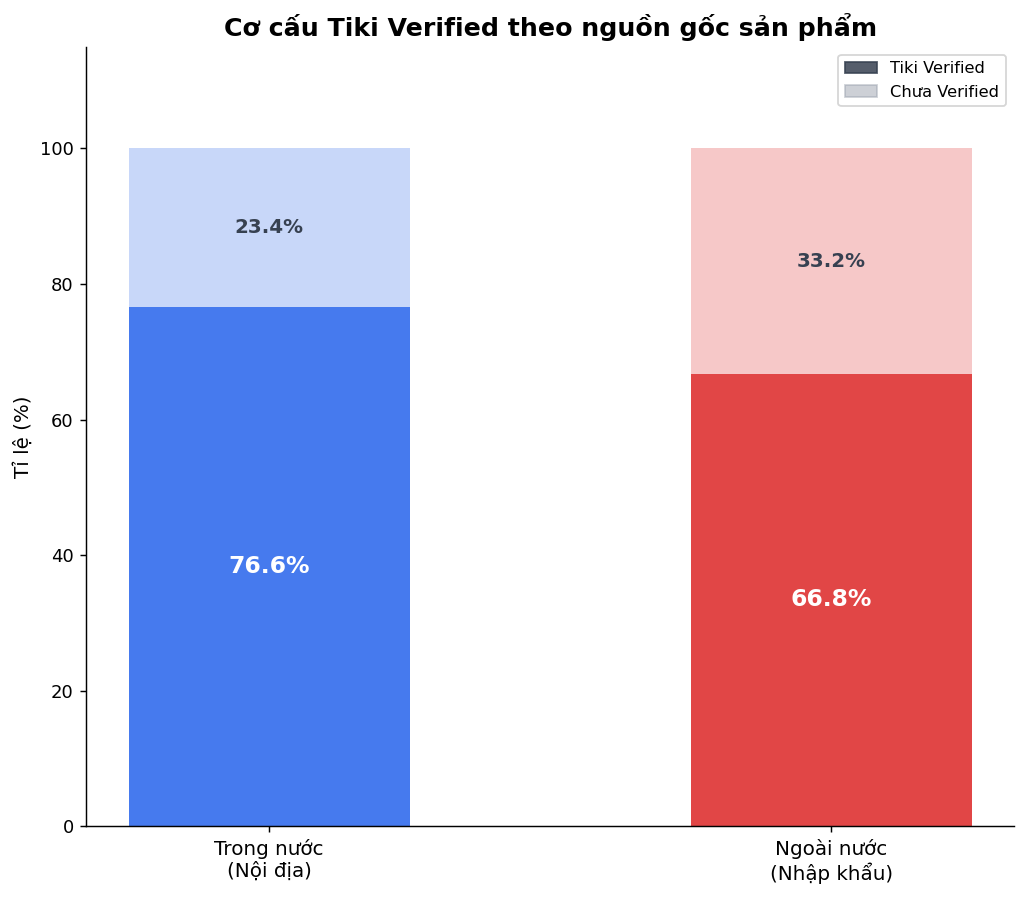

In [15]:
# 1. CHUẨN BỊ DỮ LIỆU

# Tỉ lệ Tiki Verified theo nhóm xuất xứ
verified_summary = df.groupby('origin_class_corrected')['tiki_verified'].agg(
    verified   = 'sum',
    total      = 'count'
).assign(
    not_verified = lambda x: x['total'] - x['verified'],
    rate_verified    = lambda x: x['verified'] / x['total'] * 100,
    rate_not         = lambda x: 100 - x['verified'] / x['total'] * 100
)

groups = ['Trong nước', 'Ngoài nước']
rates_ver  = [verified_summary.loc[g, 'rate_verified'] for g in groups]
rates_not  = [verified_summary.loc[g, 'rate_not']     for g in groups]
labels_grp = ['Trong nước\n(Nội địa)', 'Ngoài nước\n(Nhập khẩu)']

# 2. VẼ BIỂU ĐỒ
fig, ax = plt.subplots(figsize=(8, 7))

# ── Panel 1: Stacked bar ──────────────────────────────────────────────────────
x = np.arange(2)
ax.bar(x, rates_ver, color=[C_DOMESTIC, C_IMPORT], alpha=0.85, width=0.5, label='Tiki Verified')
ax.bar(x, rates_not, bottom=rates_ver, color=[C_DOMESTIC, C_IMPORT],
        alpha=0.25, width=0.5, label='Chưa Verified')

for i, (rv, rn) in enumerate(zip(rates_ver, rates_not)):
    ax.text(i, rv / 2,       f'{rv:.1f}%',  ha='center', va='center',
             fontweight='bold', fontsize=13, color='white')
    ax.text(i, rv + rn / 2,  f'{rn:.1f}%',  ha='center', va='center',
             fontweight='bold', fontsize=11, color='#374151')

ax.set_xticks(x)
ax .set_xticklabels(labels_grp, fontsize=11)
ax.set_ylabel('Tỉ lệ (%)')
ax.set_ylim(0, 115)
ax.set_title('Cơ cấu Tiki Verified theo nguồn gốc sản phẩm', fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#374151', alpha=0.85, label='Tiki Verified'),
    mpatches.Patch(color='#9CA3AF', alpha=0.5,  label='Chưa Verified'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ cơ cấu Tiki Verified theo nguồn gốc sản phẩm, ta rút ra một số nhận xét sau:

- Hàng Trong nước có tỉ lệ Tiki Verified cao hơn (76,6%) so với hàng Ngoài nước (66,8%) — chênh lệch gần 10%. Đây là kết quả đáng chú ý: thương hiệu nội địa đang chủ động đầu tư vào việc xây dựng uy tín trên nền tảng Tiki nhiều hơn so với hàng nhập khẩu.

- Tỉ lệ Tiki Verified của hàng ngoài nước chỉ đạt 66,8% — đồng nghĩa với việc hơn 1/3 sản phẩm nhập khẩu chưa được Tiki xác nhận. Điều này có thể phản ánh độ phức tạp trong quy trình xác nhận đối với thương hiệu quốc tế, hoặc một số thương hiệu chưa ưu tiên đầu tư vào Tiki.

#### Biểu đồ cột nhóm về lượt bán trung bình giữa sản phẩm Đã Verified vs Chưa Verified:
Biểu đồ thể hiện hiệu quả (dựa trên lượt bán trung bình) giữa các sản phẩm từ gian hàng đã có Tiki Verified và Chưa Verified, từ đó thấy rõ được tầm quan trong của Tiki Verified, hay nói rộng hơn là độ uy tín của thương hiệu.

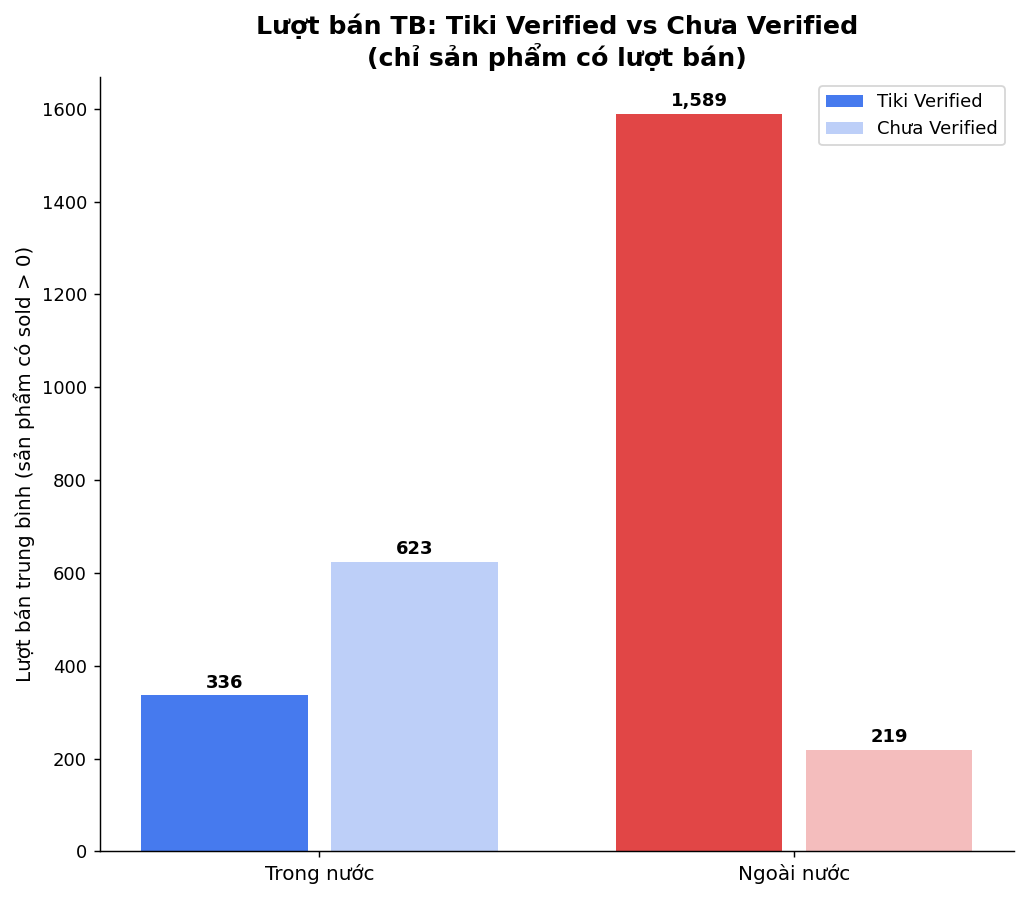

In [16]:
# Tiki Verified theo product_type x origin
tv_pt = df.groupby(['product_type', 'origin_class_corrected'])['tiki_verified'].mean().unstack() * 100
tv_pt = tv_pt.sort_values('Trong nước', ascending=False)

# Tác động của Tiki Verified lên lượt bán và review (chỉ sp có lượt bán)
df_sold = df[df['sold_count'] > 0].copy()
impact = df_sold.groupby(['origin_class_corrected', 'tiki_verified']).agg(
    avg_sold       = ('sold_count',    'mean'),
    avg_reviews    = ('review_count',  'mean'),
    pct_has_review = ('review_count',  lambda x: (x > 0).mean() * 100)
).round(1)

fig, ax2 = plt.subplots(figsize=(8, 7))

groups_plot = ['Trong nước', 'Ngoài nước']
ver_sold    = [impact.loc[(g, 1), 'avg_sold']    for g in groups_plot]
not_sold    = [impact.loc[(g, 0), 'avg_sold']    for g in groups_plot]
ver_review  = [impact.loc[(g, 1), 'avg_reviews'] for g in groups_plot]
not_review  = [impact.loc[(g, 0), 'avg_reviews'] for g in groups_plot]

x2 = np.arange(2)
bv = ax2.bar(x2 - 0.2, ver_sold, 0.35, color=[C_DOMESTIC, C_IMPORT], alpha=0.85, label='Tiki Verified')
bn = ax2.bar(x2 + 0.2, not_sold, 0.35, color=[C_DOMESTIC, C_IMPORT], alpha=0.30, label='Chưa Verified')

for bar, v in zip([*bv, *bn], [*ver_sold, *not_sold]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             f'{v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax2.set_xticks(x2)
ax2.set_xticklabels(['Trong nước', 'Ngoài nước'], fontsize=11)
ax2.set_ylabel('Lượt bán trung bình (sản phẩm có sold > 0)')
ax2.set_title('Lượt bán TB: Tiki Verified vs Chưa Verified\n(chỉ sản phẩm có lượt bán)', fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ cột nhóm về lượt bán trung bình Tiki Verified vs Chưa Verified, ta rút ra một số nhận xét sau:

- Hàng Ngoài nước: Tiki Verified tạo ra lợi thế bán hàng rõ rệt — sản phẩm đã Verified đạt trung bình 1.589 lượt bán/sản phẩm, gấp hơn 7 lần so với sản phẩm chưa Verified (chỉ 219 lượt). Đây là bằng chứng trực tiếp cho thấy người tiêu dùng Việt Nam đặt yếu tố xác thực chính hãng lên hàng đầu khi lựa chọn hàng nhập khẩu — vốn khó kiểm chứng xuất xứ bằng mắt thường.

- Hàng Trong nước cho thấy chiều ngược lại đáng chú ý: sản phẩm chưa Verified lại bán trung bình 623 lượt/sản phẩm — cao hơn gần gấp đôi sản phẩm đã Verified (336 lượt). Điều này không có nghĩa là uy tín không quan trọng với hàng nội, mà phản ánh đặc thù cấu trúc dữ liệu: nhóm "Chưa Verified" nội địa bao gồm nhiều thương hiệu quen thuộc, đại trà (kem đánh răng, dầu gội, sữa tắm phổ thông) vốn đã có lượt bán cao nhờ nhận diện thương hiệu sẵn có, dù chưa đầu tư vào quy trình xác minh trên Tiki. Họ không cần "con dấu" Tiki Verified để được người tiêu dùng tin tưởng vì đã xây dựng uy tín qua kênh offline từ lâu.

**Kết luận:**

Mục tiêu 1 đặt câu hỏi: nhóm nào đang đầu tư xây dựng uy tín trên Tiki nhiều hơn, và điều đó có tạo ra lợi thế bán hàng thực sự không? Dữ liệu cho thấy câu trả lời không đơn giản như tưởng tượng.

Về mức độ đầu tư, hàng nội địa đang chủ động hơn — tỉ lệ Verified 76,6% so với 66,8% của hàng ngoại. Điều này có lẽ phản ánh áp lực cạnh tranh thực tế: thương hiệu Việt hiểu rằng nếu không có dấu xác nhận, người mua sẽ ưu tiên hàng ngoại vốn đã có tên tuổi quốc tế. Ngược lại, nhiều thương hiệu ngoại không cần Tiki Verified để bán được — thương hiệu toàn cầu của họ đã là "dấu xác nhận" theo nghĩa riêng.

Nhưng tác động lên lượt bán thì lại kể một câu chuyện khác hoàn toàn. Với hàng nhập khẩu, Verified tạo ra chênh lệch gấp 7 lần — rõ ràng, trực tiếp, không có ngoại lệ. Với hàng nội địa thì ngược lại: nhóm chưa Verified bán nhiều hơn gần gấp đôi, vì đó chủ yếu là các thương hiệu đại trà có lượng khách trung thành từ kênh offline, không phụ thuộc vào bất kỳ nhãn xác nhận online nào.

Tóm lại: Tiki Verified không phải công thức chung cho mọi thương hiệu. Với hàng ngoại, đây là điều kiện gần như bắt buộc để cạnh tranh trên sàn. Với hàng nội địa, nó quan trọng nhưng chưa đủ — niềm tin người tiêu dùng với thương hiệu Việt vẫn được xây từ nơi khác, không phải từ một dấu kiểm trên Tiki.

## **2.2. Mục tiêu 2:** Dựa trên dữ liệu tháng 3/2026, xác định hồ sơ Top 10 thương hiệu nội địa và quốc tế có doanh thu ước tính cao nhất nhằm nhận diện những đơn vị đang dẫn dắt thị phần mỹ phẩm.

### **2.2.1. Lí do chọn mục tiêu**

Doanh thu ước tính (estimated_revenue = price × sold_count) là chỉ số tổng hợp phản ánh cả sức hấp dẫn về giá lẫn khả năng chuyển đổi lượt bán — tức là "tiền thực tế" mà một thương hiệu tạo ra trên Tiki. Xếp hạng Top 10 theo chỉ số này giúp:

- Đối với *doanh nghiệp nội địa*: Nhận ra khoảng cách và điểm mạnh của mình so với các thương hiệu quốc tế dẫn đầu, từ đó xác định chiến lược cạnh tranh phù hợp.

- Đối với *nhà bán hàng và nhà đầu tư*: Biết được đâu là thương hiệu đang thống trị từng phân khúc để đưa ra quyết định phân phối hay đầu tư.

- Đối với *người tiêu dùng*: Hiểu được thương hiệu nào đang được thị trường tin dùng chọn mua nhiều nhất, biết được mức độ tin tưởng của cộng đồng với thương hiệu.

### **2.2.2. Phân tích và trực quan hóa dữ liệu**

**Hành động cụ thể**: Phân tích, so sánh, lọc.

**Biểu đồ lựa chọn:**

- *Biểu đồ thanh ngang (Horizontal Bar Chart):* Lý tưởng để xếp hạng Top 10 vì tên thương hiệu dài được hiển thị rõ trên trục Y mà không bị chồng chéo. Hai subplot đặt cạnh nhau cho phép đối chiếu ngay lập tức giữa Top nội và Top ngoại.

- *Biểu đồ bong bóng (Bubble Chart):* Mỗi bong bóng là một thương hiệu, trục X là giá trung bình, trục Y là tổng lượt bán, kích thước bong bóng là doanh thu ước tính. Biểu đồ này tiết lộ chiến lược định vị của từng thương hiệu: Thương hiệu nào đang đánh vào số lượng bán ra (bán nhiều, giá thấp) và thương hiệu nào đánh vào giá cả (bán ít, giá cao).

#### Biểu đồ thanh ngang — Top 10 thương hiệu theo doanh thu ước tính (Tháng 03/2026):

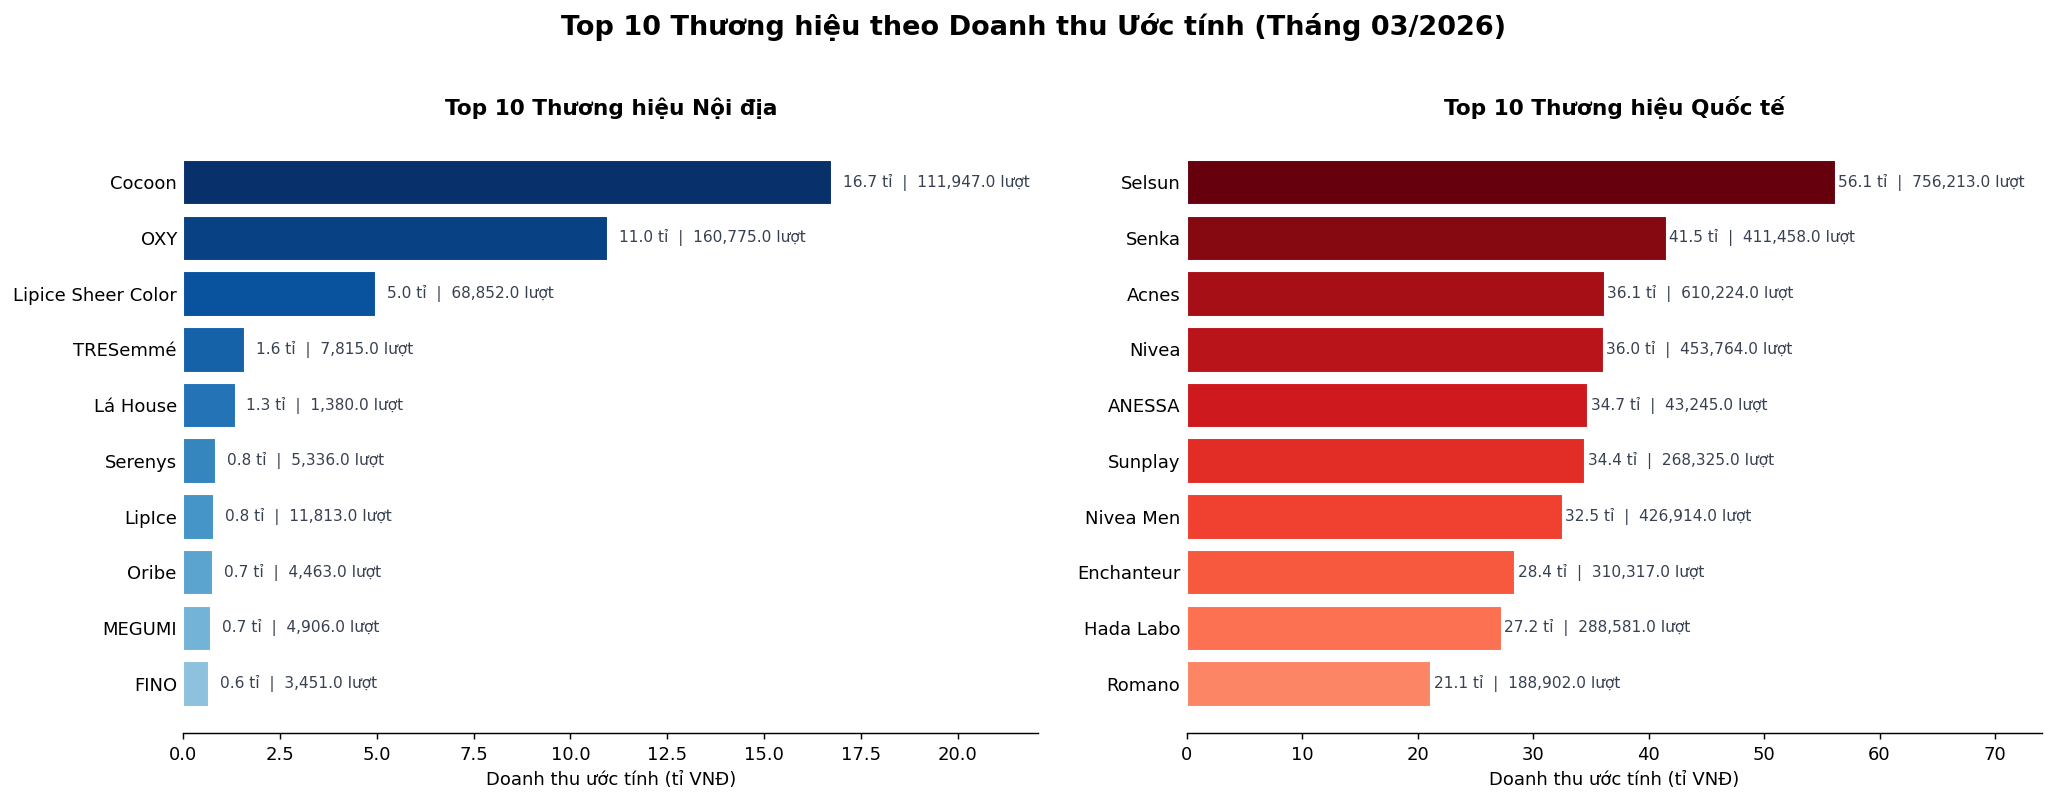

In [17]:
# 1. CHUẨN BỊ DỮ LIỆU
def get_brand_profile(df_sub, top_n=10):
    profile = df_sub.groupby('brand_name').agg(
        revenue    = ('estimated_revenue', 'sum'),
        products   = ('product_id',        'count'),
        sold_total = ('sold_count',         'sum'),
        avg_price  = ('price',              'mean'),
        avg_rating = ('rating',             lambda x: x[x > 0].mean() if (x > 0).any() else 0)
    ).sort_values('revenue', ascending=False).head(top_n)
    profile['rev_B'] = profile['revenue'] / 1e9
    return profile

top10_vn = get_brand_profile(df_vn, 10)
top10_nn = get_brand_profile(df_nn, 10)

# 2. VẼ BIỂU ĐỒ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Thương hiệu theo Doanh thu Ước tính (Tháng 03/2026)',
             fontsize=15, fontweight='bold', y=1.02)

configs = [
    (axes[0], top10_vn, plt.cm.Blues,  'Top 10 Thương hiệu Nội địa'),
    (axes[1], top10_nn, plt.cm.Reds,   'Top 10 Thương hiệu Quốc tế'),
]

for ax, data, cmap, title in configs:
    n      = len(data)
    # Gradient màu: thứ hạng cao → màu đậm hơn
    colors = [cmap(0.35 + 0.65 * (1 - i / n)) for i in range(n)]
    bars   = ax.barh(
        data.index[::-1], data['rev_B'][::-1],
        color=colors[::-1], edgecolor='white', linewidth=0.6
    )
    # Nhãn: doanh thu + lượt bán
    for bar, (_, row) in zip(bars, data.iloc[::-1].iterrows()):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{row['rev_B']:.1f} tỉ  |  {row['sold_total']:,} lượt",
            va='center', fontsize=8.5, color='#374151'
        )
    ax.set_xlabel('Doanh thu ước tính (tỉ VNĐ)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.margins(x=0.32)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ thanh ngang về Top 10 thương hiệu theo doanh thu ước tính, ta rút ra một số nhận xét sau:

- *Cocoon dẫn đầu nhóm nội địa* với 16,7 tỉ VNĐ và 111.947 lượt bán từ 243 sản phẩm — mức doanh thu đáng chú ý cho một thương hiệu thuần Việt. OXY đứng thứ hai (11,0 tỉ, 160.775 lượt) nhờ số lượng lượt bán cao hơn nhưng giá thấp hơn. Phần còn lại của Top 10 nội có khoảng cách khá xa, dao động trong vùng 0,6–5,0 tỉ.

- *Selsun thống trị nhóm quốc tế* với 56,1 tỉ VNĐ và 756.213 lượt bán — bỏ xa vị trí thứ hai là Senka (41,5 tỉ). Điều đặc biệt: Selsun chỉ có số sản phẩm rất ít nhưng đạt lượt bán khổng lồ, điển hình của chiến lược "ít nhưng mạnh", tập trung vào vài sản phẩm chủ lực và khai thác triệt để phân khúc đại trà (dầu gội trị gàu).

- *Khoảng cách doanh thu giữa Top nội và Top ngoại rất lớn*: thương hiệu dẫn đầu nội địa (Cocoon 16,7 tỉ) chỉ bằng khoảng 30% so với thương hiệu dẫn đầu quốc tế (Selsun 56,1 tỉ). Nhóm ngoại Top 10 đều vượt 21 tỉ, trong khi nhóm nội sau vị trí 2 (OXY) đã tụt xuống dưới 5 tỉ — cho thấy hàng nội thiếu chiều sâu thương hiệu mạnh.

- *Hàng nội địa lệ thuộc vào volume, hàng ngoại đa dạng chiến lược hơn.* Nhóm nội hầu hết cần lượt bán lớn ở mức giá thấp để đạt doanh thu. Nhóm ngoại vừa có "volume player" (Nivea Men: 426k lượt) vừa có "premium player" (ANESSA: 43k lượt, 34,7 tỉ) — sự đa dạng này giúp hàng ngoại phủ sóng nhiều phân khúc khách hàng hơn.


#### Biểu đồ bong bóng — Định vị chiến lược thương hiệu (Giá × Lượt bán × Doanh thu):

Biểu đồ này cho thấy chiến lược của từng thương hiệu — ai đang cạnh tranh ở phân khúc nào và bằng cách nào.

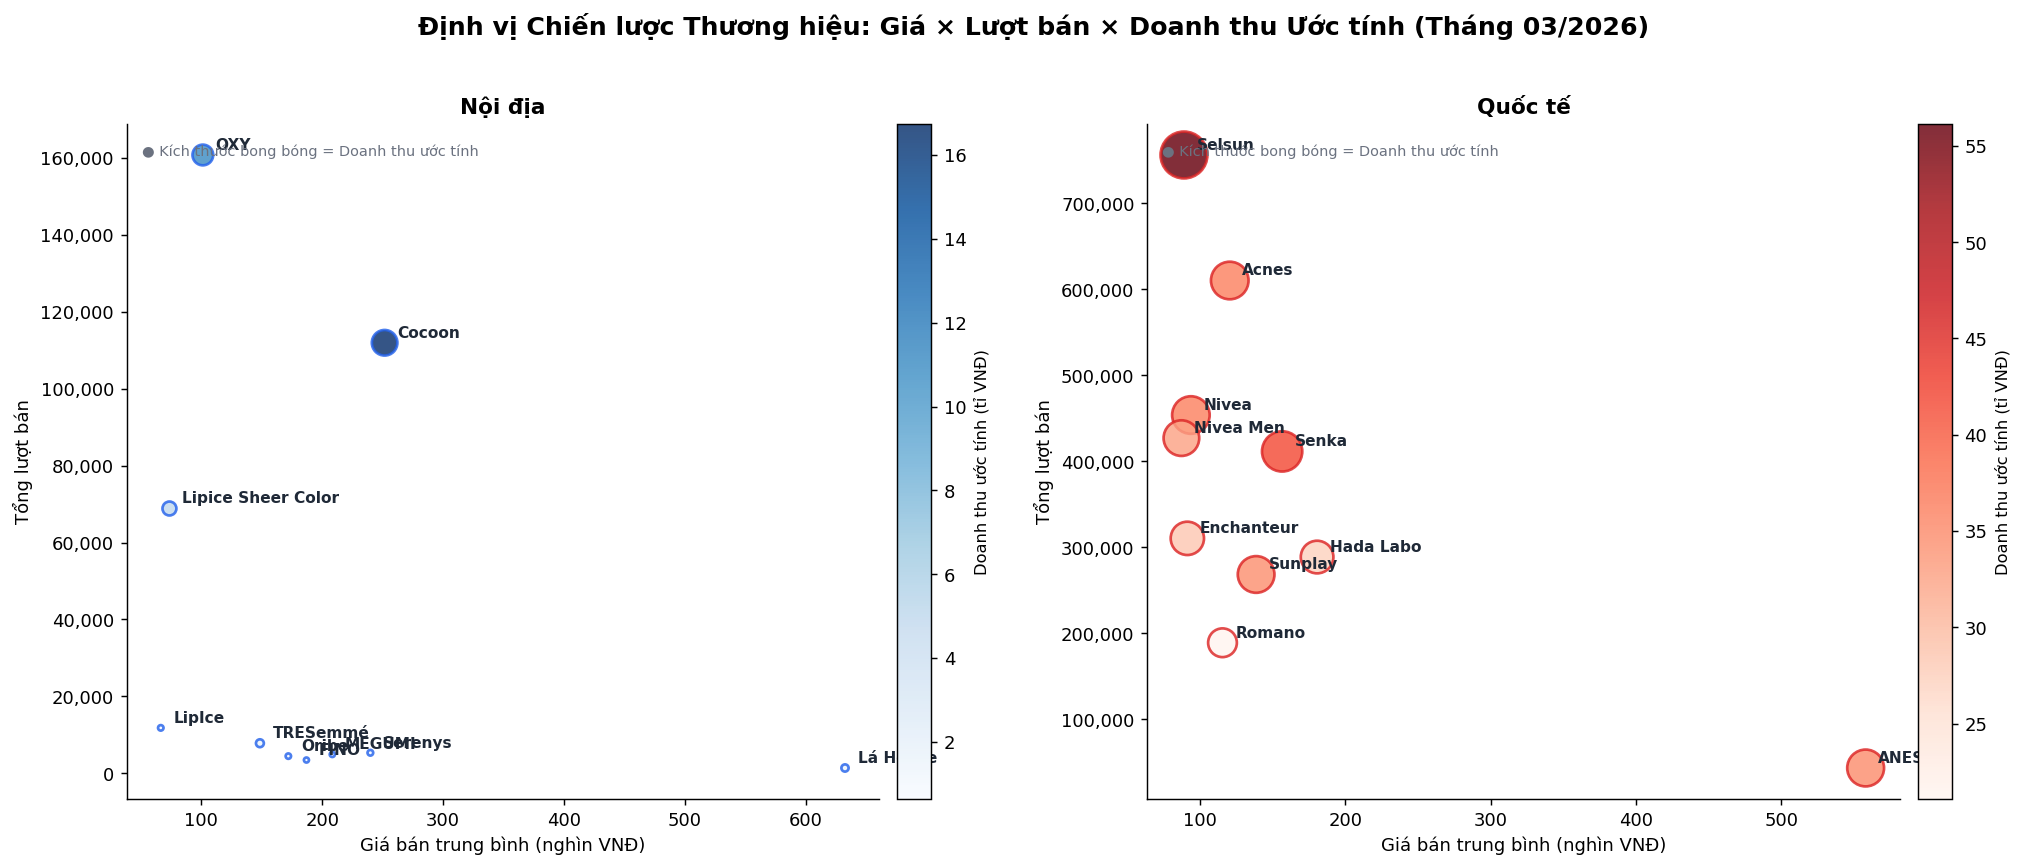

In [18]:
# VẼ BUBBLE CHART — Định vị chiến lược
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle('Định vị Chiến lược Thương hiệu: Giá × Lượt bán × Doanh thu Ước tính (Tháng 03/2026)',
             fontsize=14, fontweight='bold', y=1.02)

configs2 = [
    (axes[0], top10_vn, 'Blues', C_DOMESTIC, 'Nội địa'),
    (axes[1], top10_nn, 'Reds',  C_IMPORT,   'Quốc tế'),
]

for ax, data, cmap_name, edge_c, title in configs2:
    sc = ax.scatter(
        data['avg_price'] / 1000,       # Trục X: giá TB (nghìn VNĐ)
        data['sold_total'],              # Trục Y: tổng lượt bán
        s     = data['rev_B'] * 12,     # Kích thước ∝ doanh thu
        c     = data['rev_B'],
        cmap  = cmap_name,
        alpha = 0.82,
        edgecolors = edge_c,
        linewidths = 1.5,
        zorder = 3
    )
    # Nhãn tên thương hiệu
    for _, row in data.iterrows():
        ax.annotate(
            row.name,
            (row['avg_price'] / 1000, row['sold_total']),
            xytext     = (7, 3),
            textcoords = 'offset points',
            fontsize   = 8.5,
            fontweight = 'bold',
            color      = '#1F2937'
        )
    # Colorbar
    cb = plt.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label('Doanh thu ước tính (tỉ VNĐ)', fontsize=9)

    ax.set_xlabel('Giá bán trung bình (nghìn VNĐ)', fontsize=10)
    ax.set_ylabel('Tổng lượt bán', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    )
    # Vùng chú thích kích thước bong bóng
    ax.text(0.02, 0.97,
            '● Kích thước bong bóng = Doanh thu ước tính',
            transform=ax.transAxes, fontsize=8, color='#6B7280',
            va='top')

plt.tight_layout()
plt.show()

#### Dựa vào biểu đồ bong bóng về định vị chiến lược thương hiệu, ta rút ra một số nhận xét sau:

- *Top Nhóm nội địa tập trung ở góc trái-trên* (giá thấp, lượt bán cao): Cocoon và OXY có lượt bán dẫn đầu nhưng cả hai đều dưới ngưỡng 300k VNĐ. Khoảng giá của toàn bộ Top 10 nội dao động 80k–680k, tuy nhiên phần lớn cụm lại dưới 300k — vùng cạnh tranh bằng số lượng là chính.

- *Lá House là ngoại lệ đáng chú ý*: giá trung bình cao (~650k, cao nhất nhóm nội) nhưng lượt bán thấp (~1.380 lượt). Bong bóng nhỏ và nằm ở góc phải-dưới, là thương hiệu đang cố định vị cao cấp nhưng chưa chuyển đổi được thành doanh thu đáng kể.

- *Nhóm quốc tế tách làm hai cực rõ ràng*: Selsun và Acnes nằm ở góc trái-trên với lượt bán 600k–750k ở mức giá dưới 100k (volume play), trong khi ANESSA đứng ở góc phải-dưới với giá ~583k và chỉ 43k lượt bán (premium play). Bong bóng ANESSA vẫn to hơn nhiều thương hiệu có lượt bán cao hơn — vì mỗi đơn hàng mang lại giá trị gấp 5–6 lần.

- *Góc phải-trên (giá cao + lượt bán lớn) hoàn toàn trống* ở cả hai nhóm — chưa có thương hiệu mỹ phẩm nào trên Tiki chinh phục được vùng "premium mass". Đây là khoảng trắng chiến lược lớn nhất của thị trường hiện tại.

**Kết luận:**

Top 10 doanh thu cho thấy mỹ phẩm nội và ngoại đang chơi hai trận đấu khác nhau trên cùng một sân. Hàng nội địa cạnh tranh bằng khối lượng — sản phẩm thiết yếu giá thấp, bán số lượng lớn để tích lũy doanh thu. Hàng ngoại thắng ở độ phủ phân khúc — có mặt từ sản phẩm đại trà giá 90k (Selsun) đến cao cấp 583k (ANESSA), và ở phân khúc nào cũng có đại diện đủ mạnh.

Điểm yếu rõ nhất của thương hiệu Việt là *thiếu chiều sâu ở giữa bảng*: sau Cocoon và OXY, doanh thu tụt xuống rất nhanh — không có thương hiệu nội thứ ba đủ mạnh để thách thức nhóm ngoại ở mức 15–30 tỉ. Cocoon đang mở đúng hướng với định vị mid-range, nhưng thị trường vẫn đang chờ một thương hiệu Việt thứ hai đi theo vết.

## **2.3. Mục tiêu 3:** Phân tích tỷ trọng số sản phẩm và doanh thu ước tính theo quốc gia xuất xứ (Hàn, Nhật, Mỹ, Pháp...) trong nhóm hàng nhập khẩu quốc tế (tháng 3/2026) để xác định Top 3 quốc gia cạnh tranh trực tiếp lớn nhất với mỹ phẩm Việt Nam.

### **2.3.1. Lí do chọn mục tiêu**

Biết "ai đang cạnh tranh" quan trọng không kém biết "ta đang đứng ở đâu". Phân tích cơ cấu quốc gia trong nhóm hàng nhập khẩu giúp:

- Đối với *thương hiệu Việt*: Xác định rõ mình đang cạnh tranh trực tiếp với quốc gia nào, ở phân khúc nào, để phân bổ nguồn lực phòng thủ đúng chỗ.

- Đối với *nhà hoạch định chính sách*: Nhận diện làn sóng nhập khẩu nào đang chiếm lĩnh thị trường mỹ phẩm nội địa, từ đó có chính sách hỗ trợ doanh nghiệp trong nước phù hợp.

- Đối với *người tiêu dùng*: Hiểu được bức tranh đa dạng của hàng nhập khẩu — không chỉ là "hàng ngoại" chung chung mà từng quốc gia có đặc trưng và phân khúc riêng.

### **2.3.2. Phân tích và trực quan hóa dữ liệu**

**Hành động cụ thể**: Phân tích, so sánh, lọc.

**Biểu đồ lựa chọn:**

- *Biểu đồ tròn kiểu donut (Donut Chart — tỷ trọng số sản phẩm):* Trả lời câu hỏi "Ai đang chiếm bao nhiêu phần trăm kệ hàng nhập khẩu?" — một góc nhìn về sức hiện diện. Donut chart phù hợp ở đây vì tổng là 100% và số lượng thành phần vừa đủ để đọc được. Trục giữa để trống cho phép hiển thị tổng số sản phẩm, giúp người đọc vừa nắm tỉ lệ vừa nắm quy mô tuyệt đối cùng lúc.

- *Biểu đồ cột đôi (Grouped Bar Chart — 2 panel):* So sánh trực tiếp Top 3 quốc gia và Việt Nam trên hai chiều: doanh thu ước tính và tổng lượt bán. Hai panel đặt cạnh nhau giúp phát hiện ngay sự chênh lệch giữa "ai chiếm tiền" (doanh thu) và "ai chiếm tần suất mua" (lượt bán) — hai thước đo bổ sung cho nhau, không thể xem riêng lẻ.

#### Biểu đồ donut về Tỷ trọng số sản phẩm theo quốc gia xuất xứ thương hiệu trong nhóm hàng nhập khẩu:

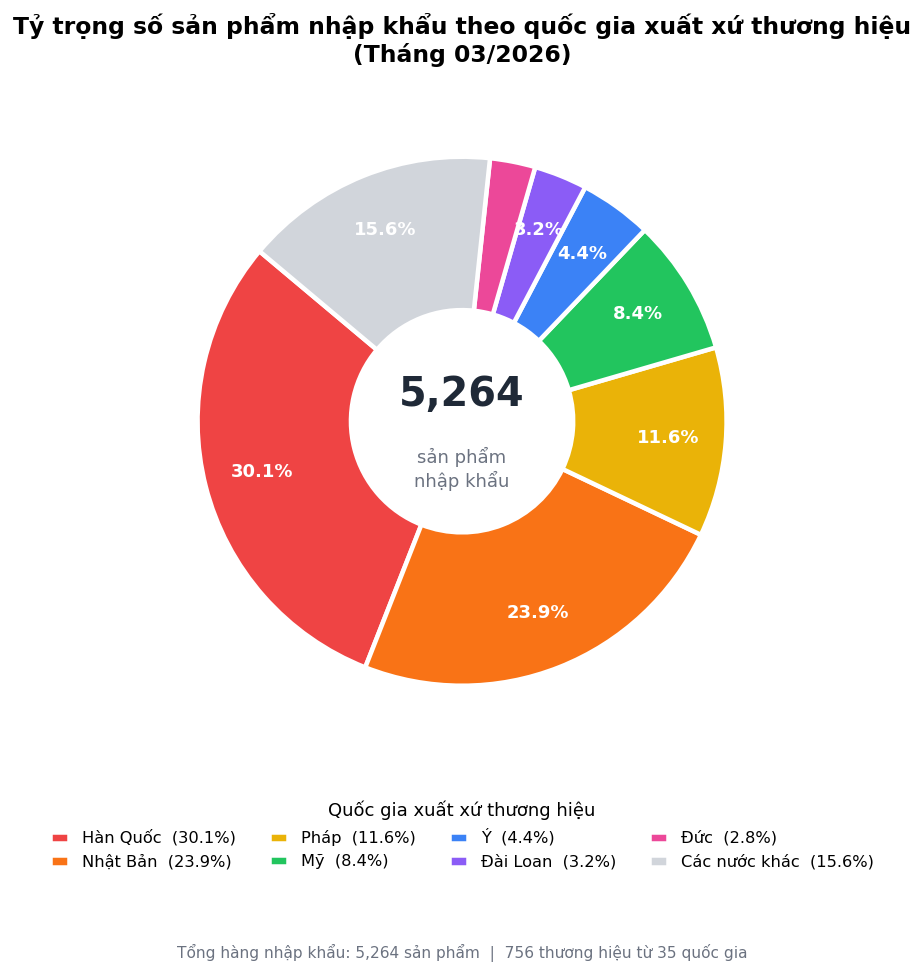

In [19]:
# 1. CHUẨN BỊ DỮ LIỆU QUỐC GIA
# Dùng origin_corrected (quốc gia gốc của thương hiệu) để phân tích đúng cạnh tranh thương hiệu
country_profile = df_nn.groupby('origin_corrected').agg(
    products = ('product_id',        'count'),
    revenue  = ('estimated_revenue', 'sum'),
    sold     = ('sold_count',        'sum'),
    brands   = ('brand_name',        'nunique'),
    avg_price= ('price',             'mean'),
).sort_values('products', ascending=False)   # sắp xếp theo số sản phẩm cho pie chart

country_profile['rev_B']   = country_profile['revenue'] / 1e9
country_profile['pct_sp']  = country_profile['products'] / country_profile['products'].sum() * 100
country_profile['pct_rev'] = country_profile['revenue']  / country_profile['revenue'].sum()  * 100

# TOP3 theo doanh thu (để dùng cho biểu đồ so sánh)
TOP3 = country_profile.sort_values('revenue', ascending=False).head(3).index.tolist()
# → ['Nhật Bản', 'Đức', 'Úc']

# Gộp "Các nước khác" — giữ top 7 quốc gia nhiều sản phẩm nhất
top7   = country_profile.head(7)
others = country_profile.iloc[7:]['products'].sum()
pie_labels = list(top7.index) + ['Các nước khác']
pie_values = list(top7['products']) + [others]

# Bảng màu: dùng COUNTRY_COLORS đã định nghĩa sẵn ở phần setup
pie_colors = COUNTRY_COLORS[:7] + ['#D1D5DB']

# 2. VẼ DONUT CHART
fig, ax = plt.subplots(figsize=(9, 7))

wedges, _, autotexts = ax.pie(
    pie_values,
    labels      = None,
    autopct     = lambda p: f'{p:.1f}%' if p > 3 else '',
    colors      = pie_colors,
    startangle  = 140,
    wedgeprops  = dict(edgecolor='white', linewidth=2.5, width=0.58),   # width < 1 → donut
    pctdistance = 0.78,
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

# Text trung tâm donut
total_sp = int(country_profile['products'].sum())
ax.text(0,  0.10, f'{total_sp:,}', ha='center', va='center',
        fontsize=22, fontweight='bold', color='#1F2937')
ax.text(0, -0.18, 'sản phẩm\nnhập khẩu', ha='center', va='center',
        fontsize=10, color='#6B7280')

# Legend gọn dưới biểu đồ
legend_labels = [
    f'{l}  ({v/total_sp*100:.1f}%)'
    for l, v in zip(pie_labels, pie_values)
]
ax.legend(
    wedges, legend_labels,
    title          = 'Quốc gia xuất xứ thương hiệu',
    title_fontsize = 10,
    loc            = 'lower center',
    bbox_to_anchor = (0.5, -0.20),
    ncol           = 4,
    fontsize        = 9,
    frameon         = False,
    handlelength    = 1.2,
)

ax.set_title(
    'Tỷ trọng số sản phẩm nhập khẩu theo quốc gia xuất xứ thương hiệu\n(Tháng 03/2026)',
    fontsize=13, fontweight='bold', pad=16
)
fig.text(0.5, -0.06,
         f'Tổng hàng nhập khẩu: {total_sp:,} sản phẩm  |  {int(country_profile["brands"].sum())} thương hiệu từ {len(country_profile)} quốc gia',
         ha='center', fontsize=8.5, color='#6B7280')

plt.tight_layout()
plt.show()


#### Dựa vào biểu đồ donut về tỷ trọng số sản phẩm nhập khẩu theo quốc gia xuất xứ thương hiệu, ta rút ra một số nhận xét sau:

- Hàn Quốc chiếm 30,1% số sản phẩm nhập khẩu, gần một phần ba kệ hàng ngoại trên Tiki mang nhãn thương hiệu Hàn. Với 1.587 sản phẩm từ 218 thương hiệu, K-beauty có danh mục rộng nhất và đa dạng nhất trong tất cả các quốc gia nhập khẩu, trải dài từ skincare đến trang điểm.

- Nhật Bản đứng thứ hai về số sản phẩm (23,9%) với 1.258 sản phẩm từ 157 thương hiệu. Tuy nhiên, khi xét doanh thu ở biểu đồ tiếp theo, Nhật Bản bứt phá lên dẫn đầu tuyệt đối — gợi ý rằng hàng Nhật có tỉ lệ chuyển đổi (doanh thu/sản phẩm) cao hơn hàng Hàn đáng kể.

- Pháp chiếm 11,6% sản phẩm (609 sản phẩm, 64 thương hiệu) — đáng kể hơn nhiều so với hình dung thông thường, phần lớn đến từ danh mục nước hoa và skincare cao cấp với giá trung bình 1,0 triệu VNĐ/sp.

- Đức và Úc chỉ chiếm 2,8% và 2,2% về số sản phẩm nhưng sẽ bất ngờ khi xét doanh thu — lý do là các thương hiệu như Nivea (Đức) và Selsun (Úc) tuy ít sản phẩm nhưng mỗi sản phẩm bán được số lượng rất lớn.

#### Biểu đồ cột thể hiện Doanh thu ước tính và Lượt bán: Top 3 quốc gia nhập khẩu vs Việt Nam (Tháng 03/2026):

Biểu đồ gồm hai panel đặt cạnh nhau: *doanh thu ước tính (tỉ VNĐ)* và *tổng lượt bán (nghìn lượt)*. Hai thước đo bổ sung cho nhau — doanh thu phản ánh ai đang "lấy tiền" của người tiêu dùng nhiều nhất, lượt bán phản ánh ai đang chiếm tần suất mua hàng. Đường nét đứt đánh dấu mức Việt Nam để so sánh trực quan với từng quốc gia.

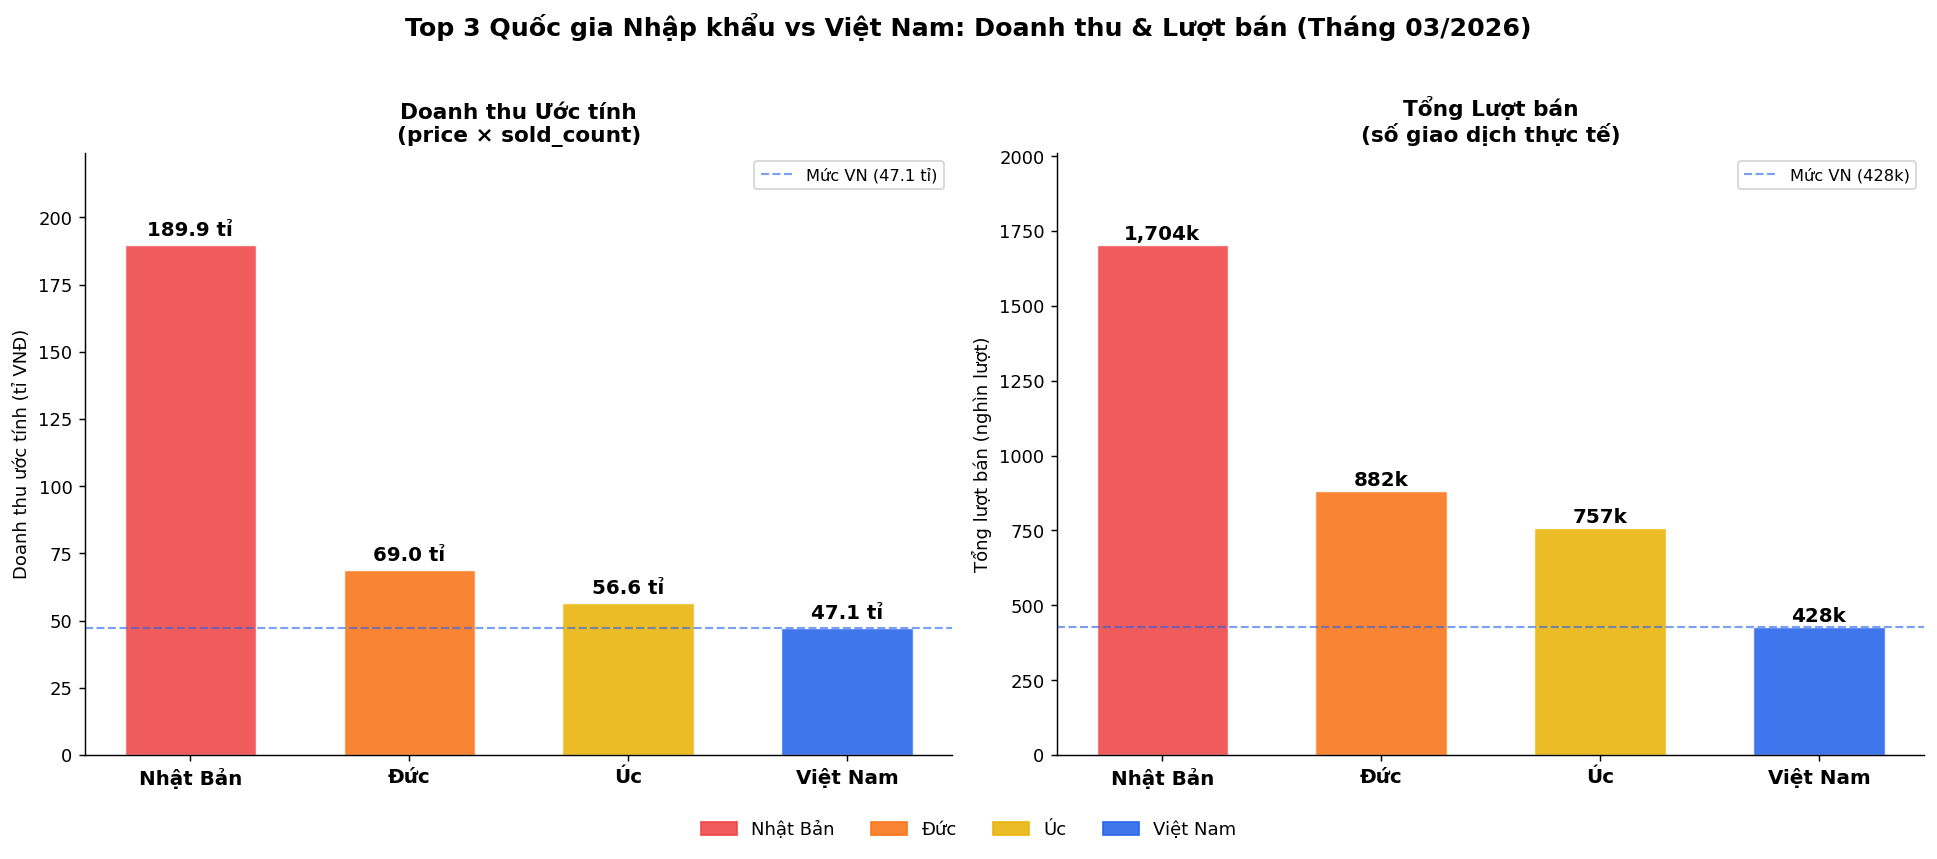

In [20]:
# 1. CHUẨN BỊ DỮ LIỆU SO SÁNH
# TOP3 theo doanh thu: ['Nhật Bản', 'Đức', 'Úc']
compare_countries = TOP3 + ['Việt Nam']

# Màu: 3 quốc gia dùng COUNTRY_COLORS, VN dùng C_DOMESTIC (xanh dương nhất quán)
bar_colors = COUNTRY_COLORS[:3] + [C_DOMESTIC]

# Dữ liệu từng quốc gia
rev_vals  = []
sold_vals = []
for c in compare_countries:
    if c == 'Việt Nam':
        rev_vals.append(df_vn['estimated_revenue'].sum() / 1e9)
        sold_vals.append(df_vn['sold_count'].sum() / 1000)
    else:
        sub = df_nn[df_nn['origin_corrected'] == c]
        rev_vals.append(sub['estimated_revenue'].sum() / 1e9)
        sold_vals.append(sub['sold_count'].sum() / 1000)

# 2. VẼ BIỂU ĐỒ 2 PANEL
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Top 3 Quốc gia Nhập khẩu vs Việt Nam: Doanh thu & Lượt bán (Tháng 03/2026)',
             fontsize=14, fontweight='bold', y=1.02)

x     = np.arange(len(compare_countries))
width = 0.6

# ── Panel trái: Doanh thu ước tính ────────────────────────────────────────
ax1 = axes[0]
bars1 = ax1.bar(x, rev_vals, width=width, color=bar_colors, alpha=0.88,
                edgecolor='white', linewidth=0.8)
for bar, val in zip(bars1, rev_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 2,
             f'{val:.1f} tỉ',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(compare_countries, fontsize=11, fontweight='bold')
ax1.set_ylabel('Doanh thu ước tính (tỉ VNĐ)', fontsize=10)
ax1.set_title('Doanh thu Ước tính\n(price × sold_count)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(rev_vals) * 1.18)
ax1.axhline(y=rev_vals[-1], color=C_DOMESTIC, linewidth=1.2,
            linestyle='--', alpha=0.6, label=f'Mức VN ({rev_vals[-1]:.1f} tỉ)')
ax1.legend(fontsize=9, loc='upper right')

# ── Panel phải: Lượt bán ─────────────────────────────────────────────────
ax2 = axes[1]
bars2 = ax2.bar(x, sold_vals, width=width, color=bar_colors, alpha=0.88,
                edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, sold_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             f'{val:,.0f}k',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(compare_countries, fontsize=11, fontweight='bold')
ax2.set_ylabel('Tổng lượt bán (nghìn lượt)', fontsize=10)
ax2.set_title('Tổng Lượt bán\n(số giao dịch thực tế)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(sold_vals) * 1.18)
ax2.axhline(y=sold_vals[-1], color=C_DOMESTIC, linewidth=1.2,
            linestyle='--', alpha=0.6, label=f'Mức VN ({sold_vals[-1]:.0f}k)')
ax2.legend(fontsize=9, loc='upper right')

# Legend màu sắc chung
legend_patches = [mpatches.Patch(color=c, label=l, alpha=0.88)
                  for c, l in zip(bar_colors, compare_countries)]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=4, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.show()


#### Dựa vào biểu đồ cột đôi so sánh Top 3 quốc gia với Việt Nam, ta rút ra một số nhận xét sau:

- Nhật Bản là đối thủ vượt trội trên cả hai chiều: doanh thu 189,9 tỉ VNĐ (gấp 4 lần Việt Nam) và 1.704k lượt bán (gấp 4 lần Việt Nam). Với 1.258 sản phẩm từ 157 thương hiệu, giá trung bình 397k VNĐ/sp, hàng Nhật kết hợp được cả chiều rộng danh mục lẫn giá trị đơn hàng — đây là đối thủ toàn diện và áp lực nhất với mỹ phẩm Việt.

- Đức: ít sản phẩm, doanh thu lớn nhờ 2 thương hiệu — Nivea và Nivea Men tạo ra gần như toàn bộ 69 tỉ doanh thu và 882k lượt bán chỉ từ 146 sản phẩm. Đây là mô hình tập trung hoàn toàn: 2/15 thương hiệu Đức chiếm trên 99% doanh thu của cả nhóm. Việt Nam vượt Đức về số sản phẩm (1.915 vs 146) nhưng thua về doanh thu gần 1,5 lần.

- Úc: trường hợp tương tự Đức nhưng còn cực đoan hơn — 56,6 tỉ doanh thu và 757k lượt bán đến từ 115 sản phẩm, trong đó Selsun một mình chiếm phần lớn nhờ chiến lược "ít sản phẩm, bán nhiều" ở phân khúc dầu gội trị gàu đại trà. Giá trung bình 1.288k VNĐ/sp là cao nhất trong 4 nhóm so sánh.

- Việt Nam (47,1 tỉ, 428k lượt) đứng cuối bảng về cả doanh thu lẫn lượt bán trong Top 3 + VN, dù có số sản phẩm nhiều nhất (1.915 sản phẩm). Đây là biểu hiện của "nhiều mà không mạnh": danh mục rộng nhưng phần lớn sản phẩm tạo ra doanh thu thấp.

**Kết luận:**

Mục tiêu 3 đặt câu hỏi: trong hàng chục quốc gia xuất khẩu mỹ phẩm vào Việt Nam, ai đang thực sự cạnh tranh trực tiếp với hàng nội? Dữ liệu chỉ ra ba cái tên — và cả ba đều đang thắng theo cách rất khác nhau.

- Nhật Bản là đối thủ đáng lo nhất, không phải vì một lý do mà vì tất cả mọi lý do cùng lúc: doanh thu 189,9 tỉ (gấp 4 lần Việt Nam), 1.704k lượt bán, 157 thương hiệu phủ từ skincare đại trà đến mid-range. Không có phân khúc nào trong tầm giá 100k–700k mà hàng Nhật không có mặt. Đây là áp lực cạnh tranh mà hàng nội phải đối mặt trực diện mỗi ngày.

- Đức thì ngược lại — chỉ 15 thương hiệu, 146 sản phẩm, nhưng tạo ra 69 tỉ nhờ Nivea và Nivea Men một mình cáng đáng gần hết. Đây là minh chứng rõ nhất cho sức mạnh của thương hiệu đã thấm sâu vào thói quen tiêu dùng: người Việt không mua "dưỡng thể" hay "lăn khử mùi" chung chung — họ mua Nivea. Khi một cái tên đã trở thành tên gọi của cả danh mục, cạnh tranh trực tiếp gần như không khả thi.

- Úc — hay đúng hơn là Selsun — lại là câu chuyện của việc thống trị một ngách cực kỳ hẹp và cực kỳ chắc. Dầu gội trị gàu không phải thế mạnh truyền thống của mỹ phẩm Việt, và 56,6 tỉ doanh thu từ chỉ vài SKU cho thấy khoảng trống đó đang bị khai thác triệt để.

Còn Hàn Quốc — 30% kệ hàng nhưng chỉ 6,6 tỉ doanh thu — là lời nhắc nhở rằng sự hiện diện đông đảo không bằng hiệu quả thực sự. K-beauty đang trong giai đoạn thâm nhập, chưa bứt phá. Nhưng nếu các thương hiệu Hàn bắt đầu đầu tư nghiêm túc hơn vào thị trường Việt, bức tranh cạnh tranh có thể thay đổi đáng kể trong vài năm tới.

Từ dữ liệu, ta thấy thị trường mỹ phẩm Việt Nam vẫn chưa thể bì với các thị trường nước ngoài, tuy nhiên với sự năng động (đa dạng trong thương hiệu và sản phẩm), tin rằng về sau với chiến lược đúng đắn thì Việt Nam vẫn có thể tiếp tục vươn lên.
